In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Target names:", data.target_names)
df.head()

Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Inspect Columns

Check all column names, shape, and data types before diving into analysis.

In [2]:
print(df.columns.tolist())
print()
print("Shape:", df.shape)
df.info()

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Shape: (569, 31)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                56

### Missing Values & Summary Statistics

Confirm there are no missing values, then look at summary stats across all features.

In [3]:
print("Missing values total:", df.isnull().sum().sum())
df.describe()

Missing values total: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Phase 2: Exploratory Data Analysis

### Class Balance

Check how many malignant vs benign cases there are.

This matters because if the classes are imbalanced, accuracy alone becomes a misleading metric later, and precision/recall need to carry more weight in evaluation.

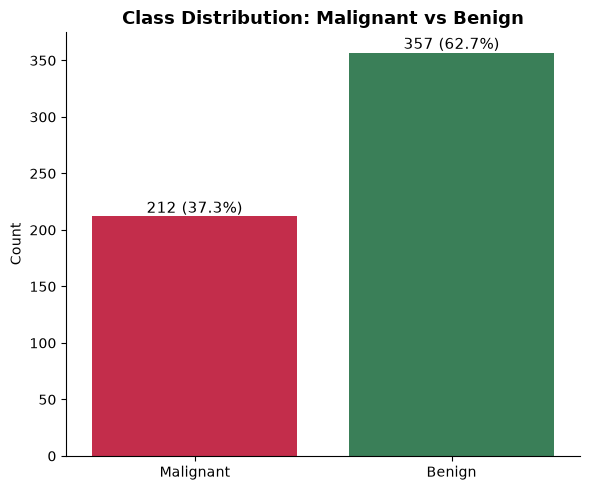

In [4]:
plt.figure(figsize=(6, 5))
colors = ['crimson', 'seagreen']  
ax = sns.countplot(x='target', data=df, hue='target', palette=colors, legend=False)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Malignant', 'Benign'])
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_title('Class Distribution: Malignant vs Benign', fontsize=13, fontweight='bold')

total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f'{count} ({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

### Correlation Heatmap

Look at how the "mean" features relate to each other and to the target. Using a subset (not all 30) to keep it readable.


**Reading this heatmap:** Values range from -1 to +1. Dark red = strong positive relationship, 
dark blue = strong negative relationship. The diagonal is always 1.00 (a feature perfectly 
correlates with itself).

**Key observation:** `mean radius`, `mean perimeter`, and `mean area` are nearly perfectly 
correlated (0.99+) since they all measure tumor size. All features are negatively correlated 
with `target` — since 0=malignant and 1=benign, this means bigger/more irregular tumors are 
associated with malignancy, matching real cancer biology.

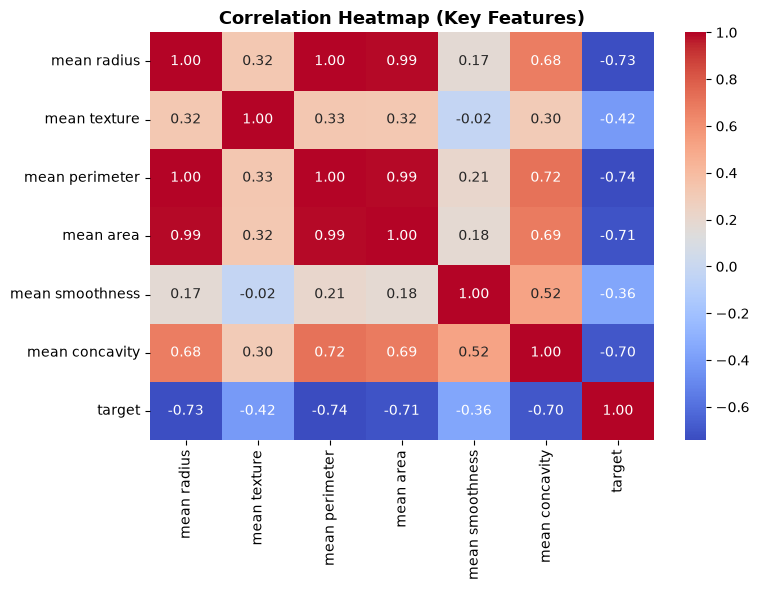

In [5]:
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                 'mean smoothness', 'mean concavity', 'target']

plt.figure(figsize=(8, 6))
sns.heatmap(df[key_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Key Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Malignant vs Benign: Key Feature Comparison

Compare the distribution of a couple of key features across the two classes using boxplots. 
This gives a visual confirmation of what the correlation heatmap suggested.

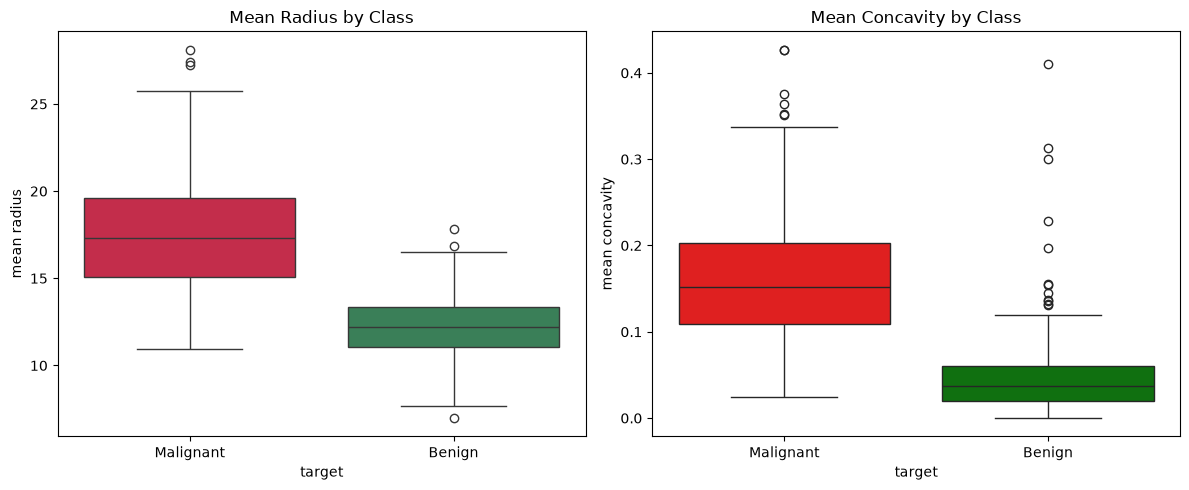

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='target', y='mean radius', data=df, hue='target', palette=['crimson', 'seagreen'], legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Malignant', 'Benign'])
axes[0].set_title('Mean Radius by Class')

sns.boxplot(x='target', y='mean concavity', data=df, hue='target', palette=['red', 'green'], legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Malignant', 'Benign'])
axes[1].set_title('Mean Concavity by Class')

plt.tight_layout()
plt.show()

**Reading the boxplots:** The box shows the middle 50% of values (25th–75th percentile), 
the line inside is the median, whiskers show the normal range, and circles are outliers.

- **Mean Radius:** Malignant tumors have a median radius of ~17, benign ~12. The boxes barely 
  overlap — radius alone is a strong separator between the two classes.
- **Mean Concavity:** Malignant tumors show a higher median (~0.15) and more spread/outliers 
  (up to 0.4), while benign tumors cluster tightly near zero (~0.03).

When two classes show boxes with little overlap like this, it's a strong early signal that the 
feature will be a useful predictor, this is confirmed before any model is even trained.

## Phase 3: Preprocessing

### Feature Scaling

Separate features (X) from the target (y), then scale the features. Scaling matters here 
because Logistic Regression and SVM are distance/gradient-based — features like `mean area` 
(range: ~150–2500) would dominate features like `mean smoothness` (range: ~0.05–0.16) if left 
unscaled, even though both might be equally important.

In [7]:
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe().loc[['mean', 'std']]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-8.241796e-16,1.248757e-17,-3.746271e-16,0.00000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.00088,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00


## Phase 4: Train/Test Split

Split the data into training (80%) and testing (20%) sets. We use `stratify=y` to make sure 
both sets keep the same malignant/benign ratio as the full dataset (roughly 37%/63%) which is
important given the mild class imbalance we saw earlier. `random_state=42` makes the split 
reproducible.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train class balance:\n", y_train.value_counts(normalize=True))
print()
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (455, 30)
Test shape: (114, 30)

Train class balance:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Test class balance:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## Phase 5: Model Training

Train four different models on the same data: Logistic Regression, Decision Tree, Random 
Forest, and SVM. Comparing multiple models (rather than just picking one) lets us justify 
which approach actually works best for this data, instead of assuming.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': CalibratedClassifierCV(SVC(random_state=42), ensemble=False)
}
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
SVM trained.


## Phase 6: Evaluation

Compare all four models using multiple metrics, not just accuracy. Given the mild class 
imbalance and the fact that a missed cancer diagnosis (false negative) is far more costly 
than a false alarm, precision, recall, and ROC-AUC matter more here than raw accuracy alone.

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

results = []
for name, model in trained_models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
3,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
2,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993717
1,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675


### Confusion Matrices

See exactly where each model makes mistakes... not just how many, but what kind. A false 
negative here (predicting benign when it's actually malignant) is the costly error, so 
we're watching that cell specifically for each model.

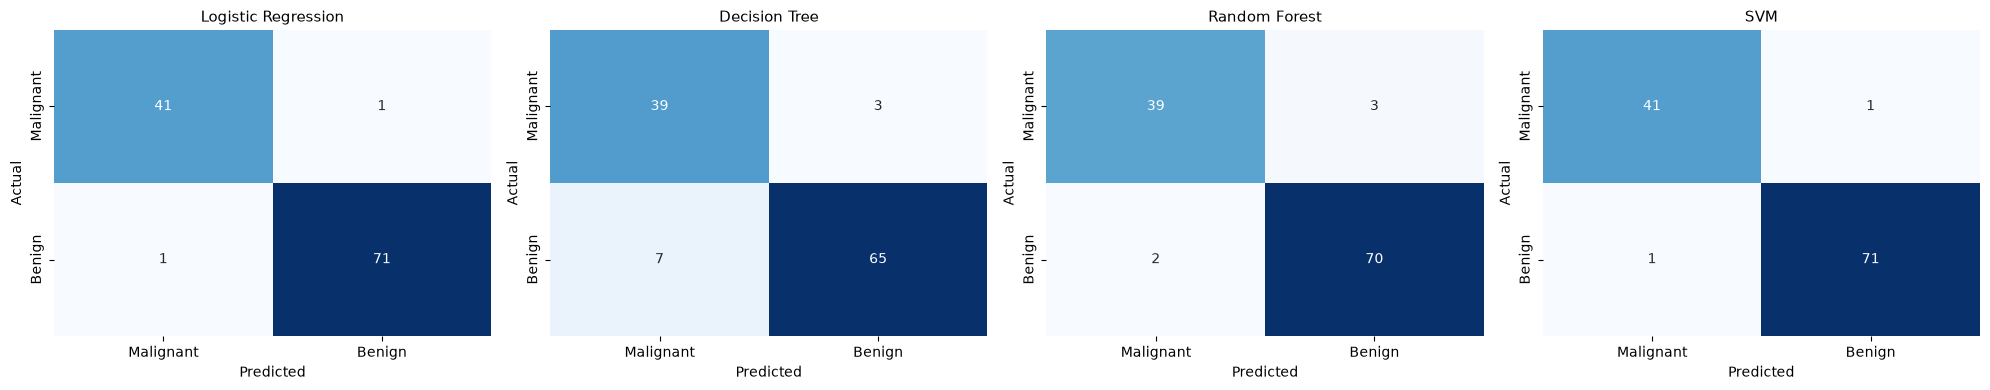

In [11]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Reading a confusion matrix:** Rows = actual class, columns = predicted class. Each cell 
counts how many times that actual class was predicted as that column's class.

- **Top-left & bottom-right (the diagonal)** = correct predictions
- **Top-right** = actual Malignant, predicted Benign - a **false negative**, the dangerous 
  mistake (a missed cancer case)
- **Bottom-left** = actual Benign, predicted Malignant - a **false positive**, a false alarm 
  (not dangerous)

**Results:** Logistic Regression and SVM each miss only 1 malignant case out of 42 
(false negatives), while Decision Tree and Random Forest miss 3. This matters more than 
the accuracy numbers alone. It's the specific mistake we most want to minimize.

### ROC Curve

Plots True Positive Rate vs False Positive Rate across every possible classification 
threshold, not just the default 50% cutoff. A curve that hugs the top-left corner indicates 
strong separation between classes. ROC-AUC (seen in the results table) is the area under 
this curve — 0.5 = random guessing, 1.0 = perfect.

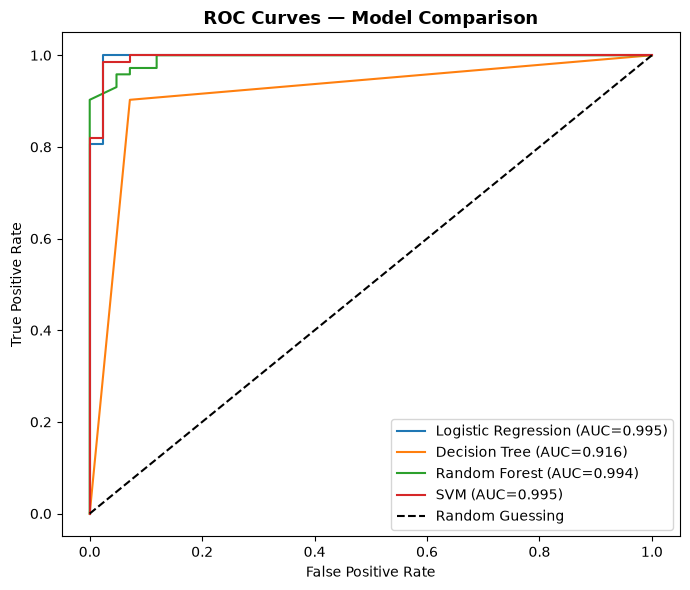

In [12]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, model in trained_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Phase 7: Feature Importance & PCA Visualization

### Feature Importance

Random Forest can tell us which features it relied on most when making predictions. This 
adds interpretability which is useful for explaining *why* the model works, not just *that* it works.

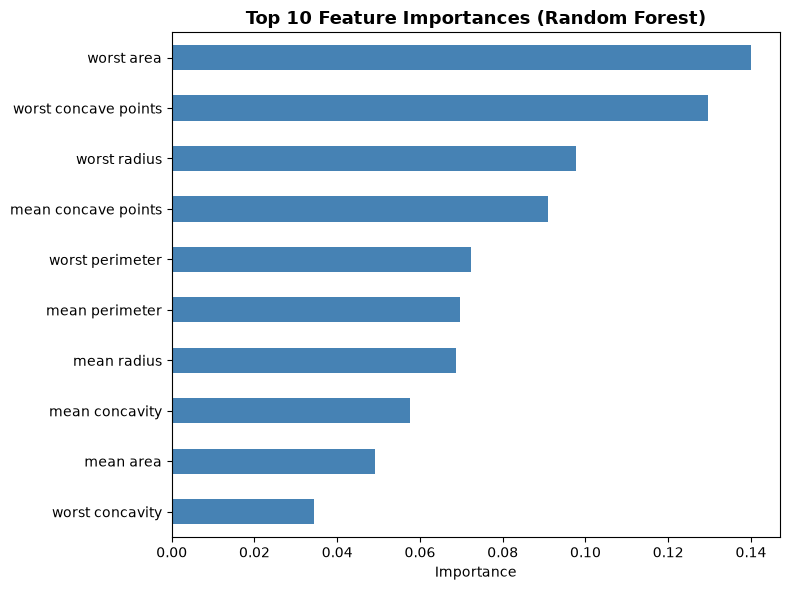

In [13]:
importances = pd.Series(
    trained_models['Random Forest'].feature_importances_, index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### PCA Visualization

The dataset has 30 features — too many to visualize directly. PCA (Principal Component 
Analysis) compresses those 30 dimensions down to 2, keeping as much of the important 
variation as possible, so we can actually plot and see how well-separated the classes are.

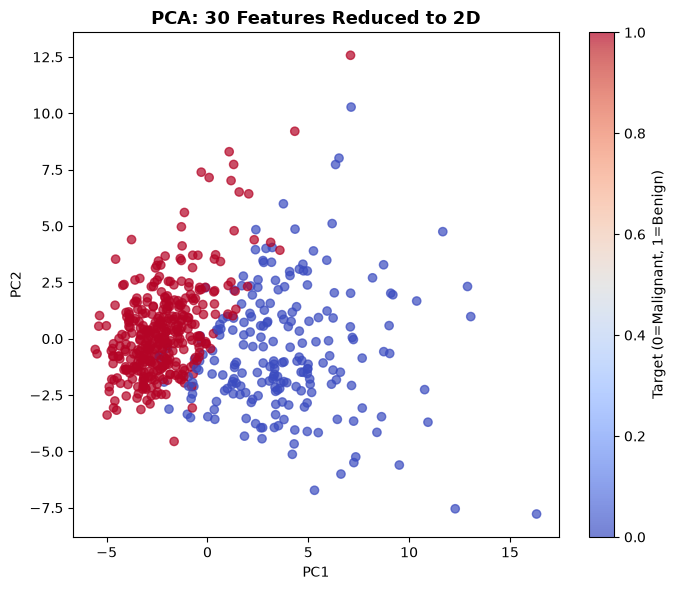

Variance explained by these 2 components: 63.24%


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: 30 Features Reduced to 2D', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Target (0=Malignant, 1=Benign)')
plt.tight_layout()
plt.show()

print(f"Variance explained by these 2 components: {pca.explained_variance_ratio_.sum():.2%}")

**Reading the PCA scatter plot:** Each dot is one patient. PC1 and PC2 aren't real 
measurements, they're mathematically blended combinations of all 30 original features, 
chosen to capture as much meaningful variation as possible in just 2 dimensions. There's 
no plain-English meaning to a specific PC1/PC2 value; what matters is whether same-colored 
points cluster together.

Red (malignant) and blue (benign) dots aren't perfectly separated, but they show clear 
regional clustering rather than random overlap. Even when compressed to two dimensions, 
malignant and benign tumors show visible clustering, suggesting the underlying features 
carry strong separating signal, consistent with the high accuracy achieved by the full 
models (which use all 30 features, not just these 2 compressed ones).

## Phase 8: Model Comparison & Justification

Bringing together everything from Phase 6 and 7 to pick a final model.

**Summary of findings:**
- Logistic Regression and SVM tied for best performance: 98.2% accuracy, ROC-AUC ≈ 0.995, 
  and only 1 false negative each out of 42 malignant test cases.
- Random Forest was close behind (95.6% accuracy, ROC-AUC 0.994) but missed 3 malignant cases.
- Decision Tree was clearly weakest (91.2% accuracy, ROC-AUC 0.916, 3 missed malignant cases) 
  — likely due to overfitting on a single tree's brittle splits, compared to the smoother 
  decision boundaries of Logistic Regression/SVM or the averaging effect of Random Forest.

**Choosing between the tied models:** Logistic Regression and SVM performed almost 
identically. Logistic Regression is chosen as the final model because it achieves the same 
accuracy and false-negative rate while being simpler, faster, and more interpretable — its 
coefficients can be directly inspected to see how each feature pushes the prediction toward 
malignant or benign, which SVM (even calibrated) does not offer as directly.

**Final model: Logistic Regression**

In [15]:
import pickle

best_model_name = 'Logistic Regression'
best_model = trained_models[best_model_name]

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Saved {best_model_name} as best_model.pkl")

Saved Logistic Regression as best_model.pkl


## Phase 9: Gradio Interface

Build a simple web interface where you input tumor measurements and get a prediction. Uses 
the saved `best_model.pkl` and `scaler.pkl` from Phase 8 — the scaler is essential here, since 
raw new input needs to be scaled the exact same way the training data was.

In [17]:
import gradio as gr
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image

with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

feature_names = list(X.columns)
mean_features = [f for f in feature_names if f.startswith('mean')]
other_features = [f for f in feature_names if f not in mean_features]
other_defaults = X[other_features].mean()

malignant_avg = df[df['target']==0][mean_features].mean()
benign_avg = df[df['target']==1][mean_features].mean()
mins, maxs = X[mean_features].min(), X[mean_features].max()

def make_radar(patient_values):
    patient = pd.Series(patient_values, index=mean_features)
    norm = lambda s: (s - mins) / (maxs - mins)
    labels = [f.replace('mean ', '') for f in mean_features]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw=dict(polar=True))
    for values, name, color in [(norm(patient), 'This Sample', 'blue'),
                                  (norm(malignant_avg), 'Avg Malignant', 'red'),
                                  (norm(benign_avg), 'Avg Benign', 'green')]:
        vals = values.tolist(); vals += vals[:1]
        ax.plot(angles, vals, label=name, color=color, linewidth=2)
        ax.fill(angles, vals, color=color, alpha=0.08)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels([])
    ax.set_title('Sample vs Typical Profiles', fontsize=11, fontweight='bold', pad=15)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf)

def confidence_gauge_html(prob, label):
    color = '#2ecc71' if label == 'Benign' else '#e74c3c'
    pct = prob * 100
    return f"""
    <div style='font-family:sans-serif; padding:16px; background:#fafafa; border-radius:10px;'>
      <div style='display:flex; justify-content:space-between;'>
        <span style='font-weight:bold; font-size:15px;'>Model Confidence</span>
        <span style='font-weight:bold; font-size:15px;'>{pct:.1f}%</span>
      </div>
      <div style='background:#e0e0e0; border-radius:20px; height:18px; width:100%; overflow:hidden; margin-top:6px;'>
        <div style='background:{color}; width:{pct}%; height:100%;'></div>
      </div>
    </div>
    """

def predict_cancer(*mean_values):
    full_input = dict(zip(mean_features, mean_values))
    full_input.update(other_defaults.to_dict())
    arr_df = pd.DataFrame([full_input])[feature_names]
    arr_scaled = pd.DataFrame(scaler.transform(arr_df), columns=feature_names)
    pred = model.predict(arr_scaled)[0]
    prob = model.predict_proba(arr_scaled)[0][pred]
    label = "Benign" if pred == 1 else "Malignant"

    if pred == 1:
        result_html = (f"<div style='padding:20px; background:#e8f8ef; border-left:6px solid #2ecc71; "
                        f"border-radius:8px;'><h2 style='color:#27ae60; margin:0;'>✅ Benign</h2></div>")
    else:
        result_html = (f"<div style='padding:20px; background:#fdecea; border-left:6px solid #e74c3c; "
                        f"border-radius:8px;'><h2 style='color:#c0392b; margin:0;'>⚠️ Malignant</h2></div>")

    gauge = confidence_gauge_html(prob, label)
    radar_img = make_radar(mean_values)
    return result_html, gauge, radar_img

def load_example(kind):
    row = df[df['target'] == (0 if kind == "malignant" else 1)][mean_features].iloc[0]
    return list(row.values)

custom_css = """
.gradio-container {max-width: 1000px !important; margin: auto;}
footer {visibility: hidden}
"""

with gr.Blocks(title="Breast Cancer Clinical Decision Support", css=custom_css) as demo:
    gr.Markdown("# 🩺 Breast Cancer Risk Classifier")
    gr.Markdown("*Clinical decision-support tool using FNA biopsy imaging measurements — for lab/clinical use, not patient self-assessment.*")

    with gr.Tabs():
        with gr.Tab("🔍 Prediction"):
            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### Cell Nuclei Measurements (from FNA imaging)")
                    inputs = [gr.Number(label=f.replace('mean ', '').title(), value=round(float(X[f].mean()), 3))
                              for f in mean_features]
                    with gr.Row():
                        example_malignant_btn = gr.Button("Load Malignant Example", size="sm")
                        example_benign_btn = gr.Button("Load Benign Example", size="sm")
                    predict_btn = gr.Button("Run Classification", variant="primary", size="lg")

                with gr.Column(scale=1):
                    gr.Markdown("### Result")
                    result_output = gr.HTML(value="<div style='padding:20px; text-align:center; color:#999;'>Awaiting input...</div>")
                    gauge_output = gr.HTML()
                    radar_output = gr.Image(label="Profile Comparison", show_label=True)

        with gr.Tab("📊 Model Performance"):
            gr.Markdown("### Test Set Results (114 held-out samples)")
            gr.Dataframe(value=results_df.round(4), interactive=False)
            gr.Markdown(
                "**Final model: Logistic Regression** — tied for best accuracy (98.2%) and ROC-AUC "
                "(0.995) with SVM, chosen for interpretability. Missed only 1 malignant case out of "
                "42 in testing (false negative), the fewest of any model tested."
            )

        with gr.Tab("ℹ️ About"):
            gr.Markdown(
                "**Data source:** Wisconsin Breast Cancer dataset — 569 samples, 30 features "
                "extracted from digitized FNA (Fine Needle Aspiration) biopsy images.\n\n"
                "**Intended users:** lab technicians / pathologists reviewing biopsy imaging "
                "output — not patients, who do not measure these values themselves.\n\n"
                "**⚠️ Disclaimer:** Educational SIWES project only. Not a certified medical "
                "device. Not for real clinical decisions."
            )

    predict_btn.click(fn=predict_cancer, inputs=inputs, outputs=[result_output, gauge_output, radar_output])
    example_malignant_btn.click(fn=lambda: load_example("malignant"), outputs=inputs)
    example_benign_btn.click(fn=lambda: load_example("benign"), outputs=inputs)

    gr.Markdown("<p style='text-align:center; color:#999; font-size:12px;'>Built by Gift Christopher — SIWES ML Project</p>")

demo.launch(share=True)

C:\Users\Danie\AppData\Local\Temp\ipykernel_8436\1744805232.py:94: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Breast Cancer Clinical Decision Support", css=custom_css) as demo:


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://675e99e2afa2efdb2c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
